In [202]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# Load Dataset

The healthcare dataset contains demographic, lifestyle, and medical information of 500 individuals. The dataset will be loaded using Pandas for further statistical analysis.

In [203]:
df = pd.read_csv("Health_Dataset_500_Records.csv")

df.head()


,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,3bd31f93-8b0d-472b-9caa-52d3f1450626,60+,79,93,Male,North,Smoker,Daily,28.9,155.9,False,True,172.8,179.4,2024-12-28
1,ea7b1d6c-b151-48d5-8021-32cc019389ef,26-35,31,92,Other,East,Non-Smoker,Never,27.8,139.9,False,False,252.6,189.6,2025-10-16
2,024cc8ea-a0f0-4784-8b4a-fe88fddc6b24,60+,73,53,Female,East,Former Smoker,Weekly,34.7,127.7,False,True,199.4,108.9,2024-10-13
3,b241522c-7fe7-4bc2-9461-8af2c5b0c773,36-45,38,79,Female,North,Former Smoker,Weekly,32.9,149.0,False,True,247.8,150.3,2024-01-24
4,29346972-c431-4f58-a7dd-5eef89e48496,26-35,34,74,Female,East,Former Smoker,Rarely,27.2,132.8,False,False,153.3,102.0,2025-02-20


# Dataset Information

This section displays the overall structure of the dataset including number of rows, columns, data types, and statistical summary.

In [204]:
print("Dataset Shape")

print(df.shape)

print()

print("Column Names")

print(df.columns)

Dataset Shape
(500, 15)

Column Names
Index(['record_id', 'age_group', 'age', 'weight', 'gender', 'region',
       'smoking_status', 'exercise_frequency', 'bmi', 'blood_pressure',
       'diabetes', 'hypertension', 'cholesterol_level', 'glucose_level',
       'visit_date'],
      dtype='str')


In [205]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           500 non-null    str    
 1   age_group           500 non-null    str    
 2   age                 500 non-null    int64  
 3   weight              500 non-null    int64  
 4   gender              500 non-null    str    
 5   region              500 non-null    str    
 6   smoking_status      500 non-null    str    
 7   exercise_frequency  500 non-null    str    
 8   bmi                 500 non-null    float64
 9   blood_pressure      500 non-null    float64
 10  diabetes            500 non-null    bool   
 11  hypertension        500 non-null    bool   
 12  cholesterol_level   500 non-null    float64
 13  glucose_level       500 non-null    float64
 14  visit_date          500 non-null    str    
dtypes: bool(2), float64(4), int64(2), str(7)
memory usage: 51.9 KB


In [206]:
df.describe(include="all")

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
count,500,500,500.000000,500.000000,500,500,500,500,500.000000,500.000000,500,500,500.000000,500.000000,500
unique,500,5,NaN,NaN,3,4,3,4,NaN,NaN,2,2,NaN,NaN,356
top,3bd31f93-8b0d-472b-9caa-52d3f1450626,36-45,NaN,NaN,Other,West,Former Smoker,Daily,NaN,NaN,False,False,NaN,NaN,2024-09-09
freq,1,115,NaN,NaN,173,145,181,142,NaN,NaN,385,381,NaN,NaN,4
mean,NaN,NaN,44.962000,76.300000,NaN,NaN,NaN,NaN,26.597400,134.882600,NaN,NaN,213.988200,127.920200,NaN
std,NaN,NaN,17.578697,19.731718,NaN,NaN,NaN,NaN,4.717381,19.893429,NaN,NaN,44.424544,34.086961,NaN
min,NaN,NaN,18.000000,45.000000,NaN,NaN,NaN,NaN,18.000000,100.000000,NaN,NaN,140.100000,70.700000,NaN
25%,NaN,NaN,32.000000,59.000000,NaN,NaN,NaN,NaN,22.700000,118.350000,NaN,NaN,174.825000,98.800000,NaN
50%,NaN,NaN,42.000000,76.000000,NaN,NaN,NaN,NaN,26.700000,135.900000,NaN,NaN,212.350000,125.250000,NaN
75%,NaN,NaN,58.250000,94.000000,NaN,NaN,NaN,NaN,30.700000,150.525000,NaN,NaN,252.300000,155.575000,NaN


# Data Cleaning

Before performing statistical analysis, it is necessary to check missing values and duplicate records.

In [207]:
print("Missing Values")

print(df.isnull().sum())

print()

print("Duplicate Records")

print(df.duplicated().sum())

Missing Values
record_id             0
age_group             0
age                   0
weight                0
gender                0
region                0
smoking_status        0
exercise_frequency    0
bmi                   0
blood_pressure        0
diabetes              0
hypertension          0
cholesterol_level     0
glucose_level         0
visit_date            0
dtype: int64

Duplicate Records
0


In [208]:
df = df.drop_duplicates()

df = df.dropna()

print("New Shape")

print(df.shape)

New Shape
(500, 15)


# Descriptive Statistics

Descriptive statistics summarize the numerical characteristics of the dataset.

In [209]:
numerical_columns = [
    "age",
    "weight",
    "bmi",
    "blood_pressure",
    "cholesterol_level",
    "glucose_level"
]

df[numerical_columns].describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.962000,76.300000,26.597400,134.882600,213.988200,127.920200
std,17.578697,19.731718,4.717381,19.893429,44.424544,34.086961
min,18.000000,45.000000,18.000000,100.000000,140.100000,70.700000
25%,32.000000,59.000000,22.700000,118.350000,174.825000,98.800000
50%,42.000000,76.000000,26.700000,135.900000,212.350000,125.250000
75%,58.250000,94.000000,30.700000,150.525000,252.300000,155.575000
max,80.000000,110.000000,35.000000,169.600000,289.900000,189.900000


In [210]:
df[numerical_columns].mean()

age                   44.9620
weight                76.3000
bmi                   26.5974
blood_pressure       134.8826
cholesterol_level    213.9882
glucose_level        127.9202
dtype: float64

In [211]:
df[numerical_columns].median()

age                   42.00
weight                76.00
bmi                   26.70
blood_pressure       135.90
cholesterol_level    212.35
glucose_level        125.25
dtype: float64

In [212]:
df[numerical_columns].std()

age                  17.578697
weight               19.731718
bmi                   4.717381
blood_pressure       19.893429
cholesterol_level    44.424544
glucose_level        34.086961
dtype: float64

# Frequency Distribution

The following tables display the distribution of categorical variables.

In [213]:
print(df["gender"].value_counts())

print()

print(df["region"].value_counts())

print()

print(df["smoking_status"].value_counts())

print()

print(df["exercise_frequency"].value_counts())

gender
Other     173
Female    172
Male      155
Name: count, dtype: int64

region
West     145
East     120
South    120
North    115
Name: count, dtype: int64

smoking_status
Former Smoker    181
Non-Smoker       167
Smoker           152
Name: count, dtype: int64

exercise_frequency
Daily     142
Never     128
Weekly    120
Rarely    110
Name: count, dtype: int64


In [214]:
print(df["diabetes"].value_counts())

print()

print(df["hypertension"].value_counts())

diabetes
False    385
True     115
Name: count, dtype: int64

hypertension
False    381
True     119
Name: count, dtype: int64


# Part A – Theoretical Foundation

## 1. What is Inferential Statistics?

Inferential statistics is a branch of statistics that uses sample data to make predictions or draw conclusions about a larger population. It helps researchers make decisions even when complete population data is unavailable.

## 2. What is Hypothesis Testing?

Hypothesis testing is a statistical method used to determine whether there is enough evidence to reject a null hypothesis (H₀). It helps determine whether the observed results are statistically significant.

## 3. Explain Confidence Interval and Critical Value

A Confidence Interval (CI) is a range of values within which the true population parameter is expected to lie with a certain confidence level (usually 95%).

A Critical Value is the threshold used to determine whether the null hypothesis should be rejected.

## 4. Define p-value

A p-value is the probability of obtaining results at least as extreme as the observed results assuming the null hypothesis is true.

If p-value < 0.05, reject H₀.
If p-value ≥ 0.05, fail to reject H₀.

## 5. Type I Error and Type II Error

Type I Error:
Rejecting a true null hypothesis.

Type II Error:
Failing to reject a false null hypothesis.

## 6. Z-Test, T-Test, Chi-Square Test and ANOVA

Z-Test:
Used for comparing sample means when population variance is known or sample size is large.

T-Test:
Used to compare means between two groups when population variance is unknown.

Chi-Square Test:
Determines whether there is an association between categorical variables.

ANOVA:
Compares the means of three or more groups.

## 7. What is Covariance?

Covariance measures how two variables change together.

Positive covariance indicates both variables increase together, while negative covariance indicates one increases as the other decreases.

## 8. What is Correlation?

Correlation measures the strength and direction of the relationship between two variables.

Its value ranges from -1 to +1.

# Part B – Statistical Analysis

## Hypothesis Formulation

We will test whether smoking has any significant effect on diabetes occurrence.

In [215]:
H0 = "Smoking has no effect on diabetes."

H1 = "Smoking affects diabetes."

print("Null Hypothesis (H0):")
print(H0)

print()

print("Alternative Hypothesis (H1):")
print(H1)

Null Hypothesis (H0):
Smoking has no effect on diabetes.

Alternative Hypothesis (H1):
Smoking affects diabetes.


# Confidence Interval

A 95% confidence interval is calculated for the Age variable.

In [216]:
import numpy as np
from scipy.stats import t

# Calculate statistics
age_mean = df["age"].mean()
age_std = df["age"].std()
n = len(df)

confidence = 0.95
alpha = 1 - confidence

critical_value = t.ppf(1 - alpha/2, df=n-1)

margin_error = critical_value * (age_std / np.sqrt(n))

lower = age_mean - margin_error
upper = age_mean + margin_error

print(f"Mean Age: {age_mean:.2f}")
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

Mean Age: 44.96
95% Confidence Interval: (43.42, 46.51)


# Confidence Interval for Weight

In [217]:
weight_mean = df["weight"].mean()

weight_std = df["weight"].std()

margin = critical_value * (weight_std / np.sqrt(n))

print("95% CI for Weight")

print(
    (
        round(weight_mean-margin,2),
        round(weight_mean+margin,2)
    )
)

95% CI for Weight
(np.float64(74.57), np.float64(78.03))


# Critical Value

The critical value at 95% confidence level is calculated below.

In [218]:
print("Critical Value")

print(round(critical_value,4))

Critical Value
1.9647


# p-value Interpretation

The p-value determines whether the null hypothesis should be rejected.

In [219]:
print("Decision Rule")

print()

print("If p-value < 0.05")

print("Reject Null Hypothesis")

print()

print("Else")

print("Fail to Reject Null Hypothesis")

Decision Rule

If p-value < 0.05
Reject Null Hypothesis

Else
Fail to Reject Null Hypothesis


In [220]:
print("Sample Size :", n)

print("Average Age :", round(age_mean,2))

print("Standard Deviation :", round(age_std,2))

print("Margin of Error :", round(margin_error,2))

Sample Size : 500
Average Age : 44.96
Standard Deviation : 17.58
Margin of Error : 1.54


# Interpretation

The confidence interval estimates the range in which the true population mean age is expected to lie with 95% confidence. This provides a reliable estimate of the population parameter.

# Independent t-Test

The Independent t-Test is used to compare the average age of individuals with diabetes and without diabetes.

### Hypotheses

**H₀:** There is no significant difference in age between diabetic and non-diabetic individuals.

**H₁:** There is a significant difference in age between diabetic and non-diabetic individuals.

In [221]:
diabetic_age = df[df["diabetes"] == True]["age"]

non_diabetic_age = df[df["diabetes"] == False]["age"]

print("Diabetic Samples :", len(diabetic_age))
print("Non-Diabetic Samples :", len(non_diabetic_age))

Diabetic Samples : 115
Non-Diabetic Samples : 385


In [222]:
t_stat, p_value = ttest_ind(
    diabetic_age,
    non_diabetic_age,
    equal_var=False
)

print("t-Statistic :", round(t_stat,4))
print("p-value :", round(p_value,4))

t-Statistic : 3.8668
p-value : 0.0002


In [223]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a significant difference in age.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no significant difference in age.")

Reject Null Hypothesis
There is a significant difference in age.


## Interpretation

The t-test compares the mean age of diabetic and non-diabetic individuals.

If the p-value is less than 0.05, we conclude that age has a statistically significant relationship with diabetes.

# Chi-Square Test

The Chi-Square Test checks whether Smoking Status and Diabetes are associated.

### Hypotheses

**H₀:** Smoking and Diabetes are independent.

**H₁:** Smoking and Diabetes are associated.

In [224]:
contingency_table = pd.crosstab(
    df["smoking_status"],
    df["diabetes"]
)

contingency_table

diabetes,False,True
smoking_status,,
Former Smoker,148,33
Non-Smoker,138,29
Smoker,99,53


In [225]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", round(chi2,4))
print("Degrees of Freedom :", dof)
print("p-value :", round(p,4))

Chi-Square Statistic : 17.4069
Degrees of Freedom : 2
p-value : 0.0002


In [226]:
if p < 0.05:
    print("Reject Null Hypothesis")
    print("Smoking has a significant association with Diabetes.")
else:
    print("Fail to Reject Null Hypothesis")
    print("Smoking has no significant association with Diabetes.")

Reject Null Hypothesis
Smoking has a significant association with Diabetes.


In [227]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

diabetes,False,True
smoking_status,,
Former Smoker,139.37,41.63
Non-Smoker,128.59,38.41
Smoker,117.04,34.96


## Interpretation

The Chi-Square Test determines whether smoking status significantly influences diabetes occurrence.

A p-value less than 0.05 indicates a significant association.

# One-Way ANOVA

ANOVA is used to compare BMI among different age groups.

### Hypotheses

**H₀:** Mean BMI is equal across all age groups.

**H₁:** At least one age group has a different mean BMI.

In [228]:
group1 = df[df["age_group"]=="18-25"]["bmi"]

group2 = df[df["age_group"]=="26-35"]["bmi"]

group3 = df[df["age_group"]=="36-45"]["bmi"]

group4 = df[df["age_group"]=="46-60"]["bmi"]

group5 = df[df["age_group"]=="60+"]["bmi"]

In [229]:
anova_result = f_oneway(
    group1,
    group2,
    group3,
    group4,
    group5
)

print(anova_result)

F_onewayResult(statistic=np.float64(0.7704403833177393), pvalue=np.float64(0.5447913277054441))


In [230]:
print("F Statistic :", round(anova_result.statistic,4))
print("p-value :", round(anova_result.pvalue,4))

F Statistic : 0.7704
p-value : 0.5448


In [231]:
if anova_result.pvalue < 0.05:
    print("Reject Null Hypothesis")
    print("BMI differs significantly among age groups.")
else:
    print("Fail to Reject Null Hypothesis")
    print("BMI does not differ significantly among age groups.")

Fail to Reject Null Hypothesis
BMI does not differ significantly among age groups.


## Interpretation

ANOVA compares the average BMI of different age groups.

If the p-value is below 0.05, at least one age group has a significantly different average BMI.

# Summary of Statistical Tests

| Test | Variable | Decision |
|------|----------|----------|
| t-Test | Age vs Diabetes | Based on p-value |
| Chi-Square | Smoking vs Diabetes | Based on p-value |
| ANOVA | BMI vs Age Group | Based on p-value |

The statistical tests above help determine whether observed differences are statistically significant.

# Covariance Analysis

Covariance measures how two numerical variables vary together. A positive covariance indicates that both variables tend to increase together, while a negative covariance indicates that one variable increases as the other decreases.

In this analysis, covariance is calculated between Age and BMI.

In [232]:
covariance = df["age"].cov(df["bmi"])

print("Covariance between Age and BMI")

print(round(covariance,4))

Covariance between Age and BMI
-2.843


## Interpretation

If covariance is positive, Age and BMI increase together.

If covariance is negative, one variable decreases while the other increases.

# Correlation Analysis

Correlation measures the strength and direction of the relationship between two variables.

The value ranges from -1 to +1.

In [233]:
correlation = df["age"].corr(df["bmi"])

print("Correlation between Age and BMI")

print(round(correlation,4))

Correlation between Age and BMI
-0.0343


In [234]:
corr_matrix = df[
    [
        "age",
        "weight",
        "bmi",
        "blood_pressure",
        "cholesterol_level",
        "glucose_level"
    ]
].corr()

corr_matrix

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
age,1.000000,0.004753,-0.034284,-0.050135,0.059971,-0.025509
weight,0.004753,1.000000,0.054609,0.005841,-0.013203,-0.007251
bmi,-0.034284,0.054609,1.000000,-0.021226,-0.029419,-0.021070
blood_pressure,-0.050135,0.005841,-0.021226,1.000000,-0.023141,-0.013118
cholesterol_level,0.059971,-0.013203,-0.029419,-0.023141,1.000000,0.018554
glucose_level,-0.025509,-0.007251,-0.021070,-0.013118,0.018554,1.000000


## Interpretation

Correlation values closer to +1 indicate a strong positive relationship.

Values closer to -1 indicate a strong negative relationship.

Values close to 0 indicate little or no linear relationship.

# Histogram

Histogram shows the distribution of Age.

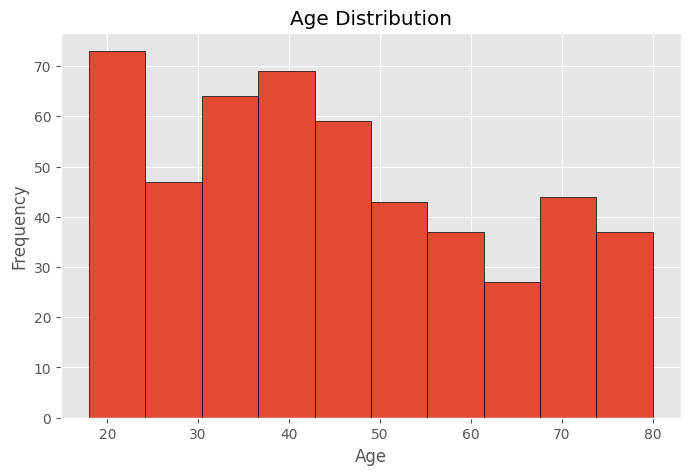

In [235]:
plt.figure(figsize=(8,5))

plt.hist(
    df["age"],
    bins=10,
    edgecolor="black"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# Bar Chart

The following chart shows the number of individuals in each region.

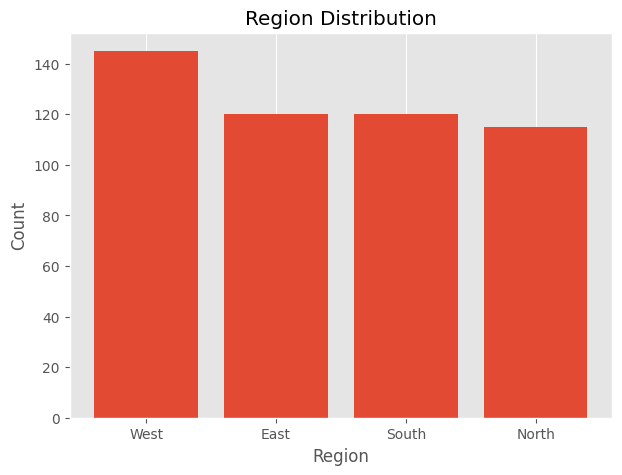

In [236]:
region_counts = df["region"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    region_counts.index,
    region_counts.values
)

plt.title("Region Distribution")

plt.xlabel("Region")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

# Pie Chart

The following chart shows the percentage distribution of Gender.

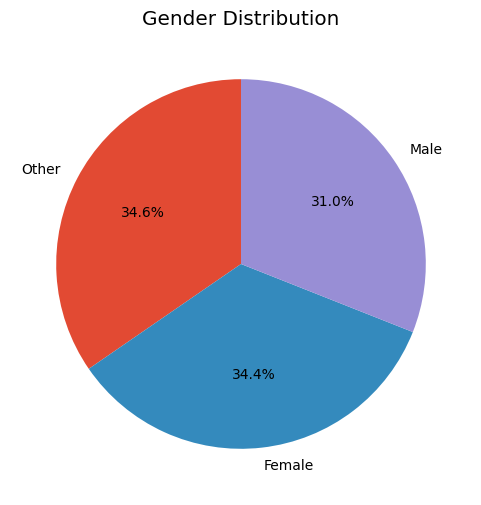

In [237]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

# Correlation Heatmap

The following heatmap displays correlations among numerical variables.

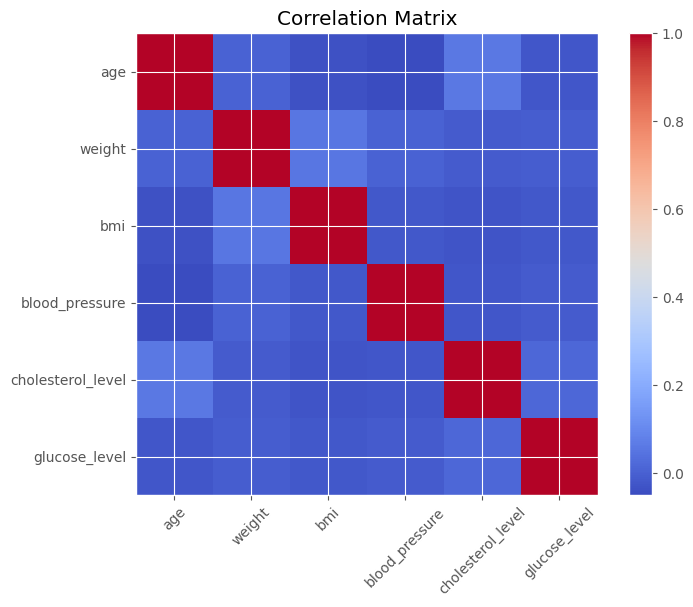

In [238]:
plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

## Interpretation of Visualizations

- Histogram shows the distribution of Age.
- Box Plot identifies outliers in BMI.
- Bar Chart compares the number of individuals in each region.
- Pie Chart displays gender distribution.
- Scatter Plot illustrates the relationship between Age and BMI.
- Correlation Matrix helps identify relationships among numerical variables.

# Final Results

The statistical analysis was performed using inferential statistical methods. The results obtained from each statistical test are summarized below.

In [239]:
print("="*60)
print("FINAL RESULTS")
print("="*60)

print("\n1. Confidence Interval")
print(f"95% Confidence Interval for Age : ({round(lower,2)}, {round(upper,2)})")

print("\n2. t-Test")
print(f"t-Statistic : {round(t_stat,4)}")
print(f"p-value : {round(p_value,4)}")

print("\n3. Chi-Square Test")
print(f"Chi-Square Statistic : {round(chi2,4)}")
print(f"p-value : {round(p,4)}")

print("\n4. ANOVA")
print(f"F Statistic : {round(anova_result.statistic,4)}")
print(f"p-value : {round(anova_result.pvalue,4)}")

print("\n5. Covariance")
print(round(covariance,4))

print("\n6. Correlation")
print(round(correlation,4))

FINAL RESULTS

1. Confidence Interval
95% Confidence Interval for Age : (43.42, 46.51)

2. t-Test
t-Statistic : 3.8668
p-value : 0.0002

3. Chi-Square Test
Chi-Square Statistic : 17.4069
p-value : 0.0002

4. ANOVA
F Statistic : 0.7704
p-value : 0.5448

5. Covariance
-2.843

6. Correlation
-0.0343


# Accept / Reject Hypothesis

The following decisions are made based on the significance level (α = 0.05).

In [240]:
print("t-Test Decision")

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

print("\nChi-Square Decision")

if p < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

print("\nANOVA Decision")

if anova_result.pvalue < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

t-Test Decision
Reject Null Hypothesis

Chi-Square Decision
Reject Null Hypothesis

ANOVA Decision
Fail to Reject Null Hypothesis


# Key Findings

The following observations were obtained from the statistical analysis.

- The dataset contains demographic, lifestyle, and health-related information of individuals.
- Confidence intervals provided reliable estimates for numerical variables.
- The Independent t-Test compared the mean age of diabetic and non-diabetic individuals.
- The Chi-Square Test evaluated the relationship between smoking status and diabetes.
- ANOVA compared BMI among different age groups.
- Covariance and Correlation measured the relationship between Age and BMI.
- Data visualization helped understand the overall distribution and trends within the dataset.

In [241]:
print("Dataset Summary")

print("-"*40)

print("Total Records :", len(df))

print("Male :", len(df[df["gender"]=="Male"]))

print("Female :", len(df[df["gender"]=="Female"]))

print("Other :", len(df[df["gender"]=="Other"]))

print("Diabetes Cases :", df["diabetes"].sum())

print("Hypertension Cases :", df["hypertension"].sum())

Dataset Summary
----------------------------------------
Total Records : 500
Male : 155
Female : 172
Other : 173
Diabetes Cases : 115
Hypertension Cases : 119


# Conclusion

This project successfully applied inferential statistical techniques to analyze healthcare data.

The statistical methods—including Confidence Interval estimation, Independent t-Test, Chi-Square Test, ANOVA, Covariance, and Correlation—provided meaningful insights into relationships among health variables.

These techniques help researchers make evidence-based decisions and identify important health factors affecting disease occurrence.

# Learning Outcomes

After completing this project, the following concepts were understood:

- Inferential Statistics
- Hypothesis Testing
- Confidence Interval
- Critical Value
- p-value
- Independent t-Test
- Chi-Square Test
- ANOVA
- Covariance
- Correlation
- Data Visualization using Python
- Statistical Interpretation

# References

1. Python Documentation
2. NumPy Documentation
3. Pandas Documentation
4. SciPy Documentation
5. Matplotlib Documentation
6. Inferential Statistics Notes